# Predição do preço do ouro com XGBoost + CV temporal + BayesSearchCV

Notebook equivalente ao script `gold_price_xgboost_cv_bayes.py`.

Mantém:
- `gold_features.csv`
- horizontes `[5, 15, 30]`
- `TimeSeriesSplit(n_splits=5)`
- busca Bayesiana com `skopt`
- paralelização dos horizontes com `multiprocessing`
- salvamento de CSVs e figuras em `experiments/price_cnn/artifacts/gold_price_xgboost_cv_bayes/`

In [ ]:
from pathlib import Path
import json
import os
import time
from concurrent.futures import ProcessPoolExecutor, as_completed

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from joblib import parallel_backend
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from xgboost.core import XGBoostError
from skopt import BayesSearchCV
from skopt.space import Integer, Real

from src import (
    make_windows,
    per_year_metrics,
    plot_predicted_vs_actual,
    plot_price_series,
    plot_return_predictions,
    plot_residuals,
    plot_scatter,
    plot_split_regions,
    plot_yearly_perf,
    regression_metrics,
)


from src import ROOT_DIR

REPO_ROOT = ROOT_DIR

SEED = 42
LOOKBACK = 60
HORIZONS = [5, 15, 30]
GAP = max(HORIZONS)
CV_SPLITS = 5
N_ITER = 16
N_JOBS_HORIZONS = min(len(HORIZONS), 3)
GPU_SEARCH_BATCHES = 2
SHOW_PLOTS = True
PREFER_GPU = True
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

CSV_PATH = REPO_ROOT / "data" / "processed" / "gold_features.csv"
EXPERIMENT_DIR = REPO_ROOT / "experiments" / "02_xgboost"
ARTIFACTS_DIR = REPO_ROOT / "outputs" / "02_xgboost"

np.random.seed(SEED)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10}
)

print("Repo root:", REPO_ROOT)

Repo root: /home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast


## Helpers

In [ ]:
def load_processed_data(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, sep=None, engine="python")
    df.columns = [c.strip().lower() for c in df.columns]
    if "date" not in df.columns or "close" not in df.columns:
        raise ValueError(f"CSV inválido. Colunas encontradas: {list(df.columns)}")
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df = df.dropna(subset=["date", "close"]).sort_values("date").reset_index(drop=True)
    return df


def select_feature_cols(df: pd.DataFrame) -> list[str]:
    blocked = {"date", "close", "open", "high", "low"}
    feature_cols = [
        col
        for col in df.columns
        if col not in blocked
        and not col.startswith("y_")
        and pd.api.types.is_numeric_dtype(df[col])
        and df[col].nunique(dropna=True) > 1
    ]
    if not feature_cols:
        raise ValueError("Nenhuma feature numérica válida encontrada.")
    return feature_cols


def flatten_windows(X: np.ndarray) -> np.ndarray:
    return X.reshape(X.shape[0], -1).astype(np.float32)


def make_window_feature_names(feature_cols: list[str], lookback: int) -> list[str]:
    names = []
    for lag in range(lookback - 1, -1, -1):
        for col in feature_cols:
            names.append(f"{col}_t-{lag}")
    return names


def show_or_close(fig: plt.Figure) -> None:
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)


def to_native(value):
    if isinstance(value, np.generic):
        return value.item()
    return value


def build_base_estimator() -> XGBRegressor:
    return XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        device="cpu",
        random_state=SEED,
        n_jobs=1,
    )


SEARCH_SPACE = {
    "n_estimators": Integer(200, 500),
    "max_depth": Integer(3, 5),
    "learning_rate": Real(0.02, 0.10, prior="log-uniform"),
    "subsample": Real(0.75, 0.95),
    "colsample_bytree": Real(0.75, 0.95),
    "min_child_weight": Integer(2, 8),
    "gamma": Real(1e-6, 0.5, prior="log-uniform"),
    "reg_alpha": Real(1e-6, 1.0, prior="log-uniform"),
    "reg_lambda": Real(0.1, 5.0, prior="log-uniform"),
}


def _gain_importances(booster: xgb.Booster, n_features: int) -> np.ndarray:
    score = booster.get_score(importance_type="gain")
    return np.array(
        [score.get(f"f{i}", 0.0) for i in range(n_features)], dtype=np.float32
    )


def train_horizon_task(
    horizon_idx: int,
    horizon: int,
    X_trainval: np.ndarray,
    Y_trainval: np.ndarray,
    X_test: np.ndarray,
    device: str,
    search_n_jobs: int,
    search_n_points: int,
    threading_backend: bool,
) -> dict:
    started_at = time.perf_counter()
    pid = os.getpid()
    tscv = TimeSeriesSplit(n_splits=CV_SPLITS)
    actual_device = device

    def make_search(run_device: str) -> BayesSearchCV:
        return BayesSearchCV(
            estimator=build_base_estimator().set_params(device=run_device),
            search_spaces=SEARCH_SPACE,
            n_iter=N_ITER,
            scoring="neg_mean_squared_error",
            cv=tscv,
            n_jobs=search_n_jobs,
            n_points=search_n_points,
            refit=True,
            random_state=SEED,
            return_train_score=True,
            verbose=0,
        )

    opt = make_search(actual_device)

    def fit_search(search: BayesSearchCV) -> None:
        if threading_backend:
            with parallel_backend("threading", n_jobs=search_n_jobs):
                search.fit(X_trainval, Y_trainval[:, horizon_idx])
        else:
            search.fit(X_trainval, Y_trainval[:, horizon_idx])

    try:
        fit_search(opt)
    except XGBoostError:
        if actual_device != "cuda":
            raise
        actual_device = "cpu"
        opt = make_search(actual_device)
        fit_search(opt)

    cv_results = (
        pd.DataFrame(opt.cv_results_)
        .sort_values("rank_test_score")
        .head(10)
        .assign(h=horizon)
    )

    booster = opt.best_estimator_.get_booster()
    return {
        "h": horizon,
        "pid": pid,
        "device": actual_device,
        "search_n_jobs": search_n_jobs,
        "search_n_points": search_n_points,
        "threading_backend": threading_backend,
        "elapsed_sec": time.perf_counter() - started_at,
        "best_score": float(opt.best_score_),
        "best_params": {k: to_native(v) for k, v in opt.best_params_.items()},
        "pred_test": booster.predict(xgb.DMatrix(X_test)).astype(np.float32),
        "cv_top10": cv_results[
            [
                "h",
                "rank_test_score",
                "mean_test_score",
                "std_test_score",
                "mean_train_score",
                "std_train_score",
                "params",
            ]
        ],
        "feature_importances": _gain_importances(booster, X_trainval.shape[1]),
    }


def probe_xgb_device(prefer_gpu: bool = True) -> str:
    if not prefer_gpu:
        return "cpu"

    X_probe = np.random.randn(32, 4).astype(np.float32)
    y_probe = np.random.randn(32).astype(np.float32)
    try:
        probe = build_base_estimator().set_params(
            device="cuda", n_estimators=2, max_depth=2
        )
        probe.fit(X_probe, y_probe, verbose=False)
        return "cuda"
    except Exception:
        return "cpu"


def log_horizon_start(
    horizon: int,
    device: str,
    search_n_jobs: int,
    search_n_points: int,
    threading_backend: bool,
    worker_pool: int | None = None,
) -> None:
    if worker_pool is None:
        print(
            f"[START] h={horizon} | device={device} | pid={os.getpid()} "
            f"| n_jobs={search_n_jobs} | n_points={search_n_points} "
            f"| threading={threading_backend}"
        )
        return
    print(
        f"[SUBMIT] h={horizon} | device={device} | worker_pool={worker_pool} "
        f"| n_jobs={search_n_jobs} | n_points={search_n_points} "
        f"| threading={threading_backend}"
    )


def consume_horizon_result(
    result: dict,
    pred_map: dict[int, np.ndarray],
    feature_importance_map: dict[int, np.ndarray],
    best_params_rows: list[dict],
    cv_score_rows: list[pd.DataFrame],
) -> None:
    h = result["h"]
    print(f"\n=== Horizonte h={h} ===")
    print(
        f"[DONE] h={h} | pid={result['pid']} | elapsed={result['elapsed_sec']:.2f}s "
        f"| n_jobs={result['search_n_jobs']} | n_points={result['search_n_points']} "
        f"| threading={result['threading_backend']}"
    )
    print("device usado:", result["device"])
    print("melhor score CV (neg MSE):", round(result["best_score"], 6))
    print("melhores params:", result["best_params"])

    pred_map[h] = result["pred_test"]
    feature_importance_map[h] = result["feature_importances"]
    best_params_rows.append(
        {
            "h": h,
            "device": result["device"],
            "best_neg_mse_cv": result["best_score"],
            **result["best_params"],
        }
    )
    cv_score_rows.append(result["cv_top10"])


def run_gpu_horizons(
    X_trainval: np.ndarray,
    Y_trainval: np.ndarray,
    X_test: np.ndarray,
    xgb_device: str,
    pred_map: dict[int, np.ndarray],
    feature_importance_map: dict[int, np.ndarray],
    best_params_rows: list[dict],
    cv_score_rows: list[pd.DataFrame],
) -> None:
    print(
        "XGBoost em CUDA detectado: rodando horizontes em processo único "
        f"com batches paralelas na busca (n_points={GPU_SEARCH_BATCHES}, n_jobs={GPU_SEARCH_BATCHES})"
    )
    print(f"Processando {len(HORIZONS)} horizontes em single-process na GPU")
    for j, h in enumerate(HORIZONS):
        log_horizon_start(h, xgb_device, GPU_SEARCH_BATCHES, GPU_SEARCH_BATCHES, True)
        result = train_horizon_task(
            j,
            h,
            X_trainval,
            Y_trainval,
            X_test,
            xgb_device,
            search_n_jobs=GPU_SEARCH_BATCHES,
            search_n_points=GPU_SEARCH_BATCHES,
            threading_backend=True,
        )
        consume_horizon_result(
            result, pred_map, feature_importance_map, best_params_rows, cv_score_rows
        )


def run_cpu_horizons(
    X_trainval: np.ndarray,
    Y_trainval: np.ndarray,
    X_test: np.ndarray,
    xgb_device: str,
    pred_map: dict[int, np.ndarray],
    feature_importance_map: dict[int, np.ndarray],
    best_params_rows: list[dict],
    cv_score_rows: list[pd.DataFrame],
) -> None:
    print(
        f"Processando {len(HORIZONS)} horizontes com {N_JOBS_HORIZONS} worker(s) em CPU"
    )
    futures = {}
    with ProcessPoolExecutor(max_workers=N_JOBS_HORIZONS) as executor:
        for j, h in enumerate(HORIZONS):
            log_horizon_start(h, xgb_device, 1, 1, False, worker_pool=N_JOBS_HORIZONS)
            future = executor.submit(
                train_horizon_task,
                j,
                h,
                X_trainval,
                Y_trainval,
                X_test,
                xgb_device,
                1,
                1,
                False,
            )
            futures[future] = h

        for future in as_completed(futures):
            result = future.result()
            consume_horizon_result(
                result,
                pred_map,
                feature_importance_map,
                best_params_rows,
                cv_score_rows,
            )

## Carregamento

In [ ]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
xgb_device = probe_xgb_device(PREFER_GPU)

df = load_processed_data(CSV_PATH)
feature_cols = select_feature_cols(df)

for h in HORIZONS:
    if f"y_{h}" not in df.columns:
        raise ValueError(f"Coluna alvo ausente: y_{h}")

print(f"{len(df)} linhas | {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"{len(feature_cols)} features:")
print(feature_cols)
print(f"XGBoost device: {xgb_device}")

6177 linhas | 2000-08-30 -> 2025-04-14
19 features:
['volume', 'log_ret_1', 'log_ret_5', 'log_ret_21', 'vol_5', 'vol_21', 'vol_ratio', 'dist_ma20', 'dist_ma50', 'ma_cross', 'rsi', 'macd_hist', 'boll_b', 'drawdown_252', 'hl_range', 'close_pos', 'gap_open', 'fear_ratio', 'fear_ma5']
XGBoost device: cuda


## Série histórica e splits

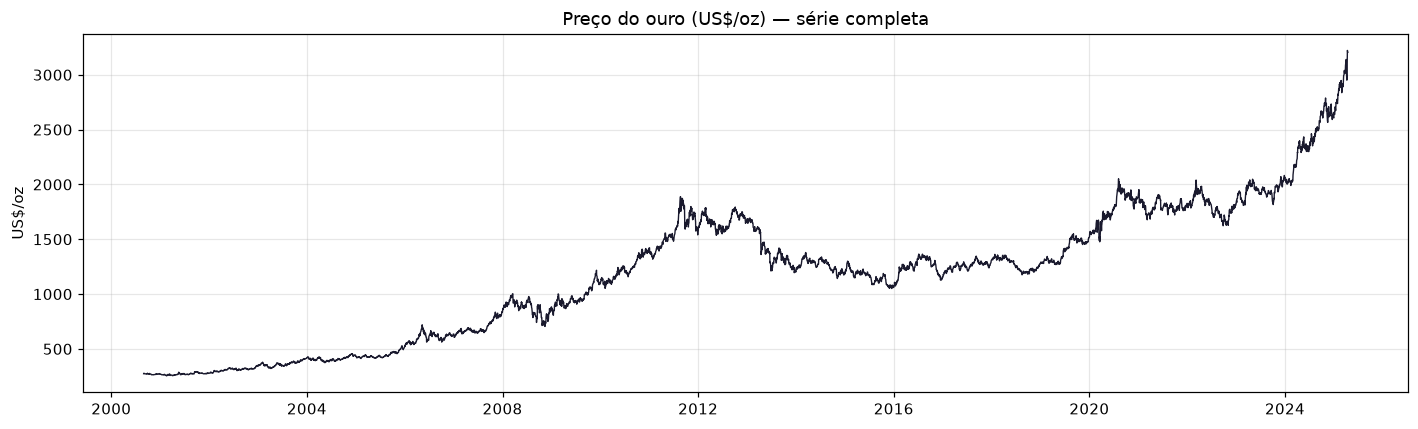

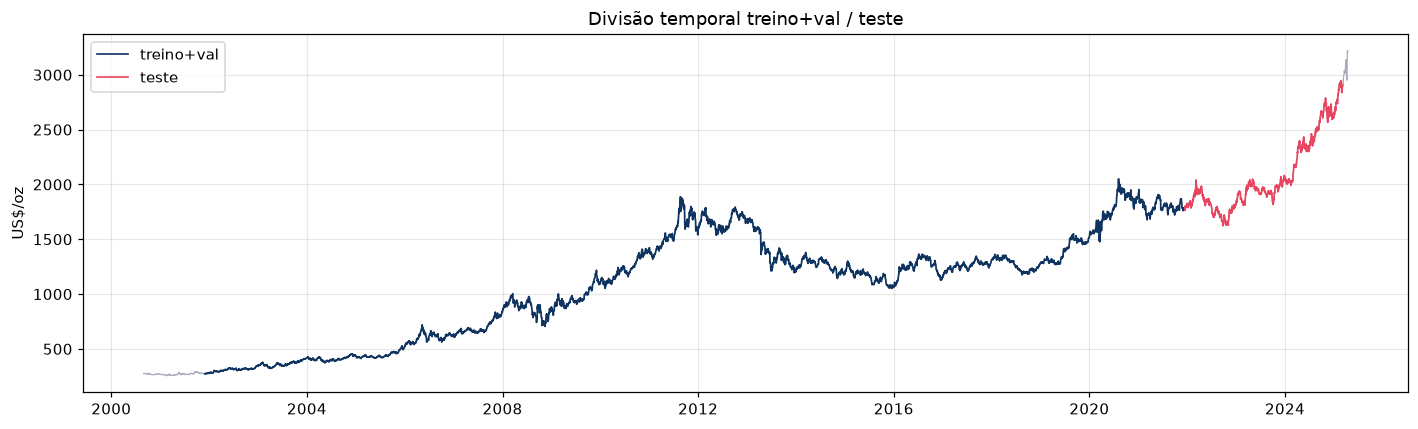

trainval: (5030, 60, 19) | 2001-11-29 -> 2021-12-13
   teste: (807, 60, 19) | 2021-12-14 -> 2025-03-03


In [ ]:
fig = plot_price_series(
    df["date"],
    df["close"],
    title="Preço do ouro (US$/oz) — série completa",
    ylabel="US$/oz",
)
fig.savefig(ARTIFACTS_DIR / "price_series.png", bbox_inches="tight")
show_or_close(fig)

n = len(df)
i1 = int(n * TRAIN_RATIO)
i2 = int(n * (TRAIN_RATIO + VAL_RATIO))
margin = GAP + LOOKBACK

trainval_end = i2 + margin
test_start = i2 + margin
test_end = n

trainval = make_windows(df, feature_cols, HORIZONS, LOOKBACK, 0, trainval_end)
test = make_windows(df, feature_cols, HORIZONS, LOOKBACK, test_start, test_end)

viz_splits = {
    "treino+val": (trainval.X, trainval.Y, trainval.prices, trainval.idx),
    "teste": (test.X, test.Y, test.prices, test.idx),
}
fig = plot_split_regions(
    df,
    viz_splits,
    title="Divisão temporal treino+val / teste",
    ylabel="US$/oz",
    split_colors={"treino+val": "#0f3460", "teste": "#e94560"},
)
fig.savefig(ARTIFACTS_DIR / "split_regions.png", bbox_inches="tight")
show_or_close(fig)

print(
    f"trainval: {trainval.X.shape} | {df['date'].iloc[trainval.idx[0]].date()} -> {df['date'].iloc[trainval.idx[-1]].date()}"
)
print(
    f"   teste: {test.X.shape} | {df['date'].iloc[test.idx[0]].date()} -> {df['date'].iloc[test.idx[-1]].date()}"
)

## Flatten

In [ ]:
X_trainval = flatten_windows(trainval.X)
Y_trainval = trainval.Y.astype(np.float32)
X_test = flatten_windows(test.X)
Y_test = test.Y.astype(np.float32)
P_test = test.prices
dates_test = df["date"].values[test.idx]
window_feature_names = make_window_feature_names(feature_cols, LOOKBACK)

print("X_trainval:", X_trainval.shape)
print("X_test:", X_test.shape)

X_trainval: (5030, 1140)
X_test: (807, 1140)


## TimeSeries CV + BayesSearchCV com multiprocessing

In [ ]:
pred_map = {}
feature_importance_map = {}
best_params_rows = []
cv_score_rows = []

if xgb_device == "cuda":
    run_gpu_horizons(
        X_trainval,
        Y_trainval,
        X_test,
        xgb_device,
        pred_map,
        feature_importance_map,
        best_params_rows,
        cv_score_rows,
    )
else:
    run_cpu_horizons(
        X_trainval,
        Y_trainval,
        X_test,
        xgb_device,
        pred_map,
        feature_importance_map,
        best_params_rows,
        cv_score_rows,
    )

best_params_rows.sort(key=lambda row: row["h"])
cv_score_rows = sorted(cv_score_rows, key=lambda df_: int(df_["h"].iloc[0]))
pred_test = np.column_stack([pred_map[h] for h in HORIZONS]).astype(np.float32)

XGBoost em CUDA detectado: rodando horizontes em processo único com batches paralelas na busca (n_points=2, n_jobs=2)
Processando 3 horizontes em single-process na GPU
[START] h=5 | device=cuda | pid=6121 | n_jobs=2 | n_points=2 | threading=True

=== Horizonte h=5 ===
[DONE] h=5 | pid=6121 | elapsed=94.11s | n_jobs=2 | n_points=2 | threading=True
device usado: cuda
melhor score CV (neg MSE): -0.00066
melhores params: {'colsample_bytree': 0.8389665024602303, 'gamma': 0.17209652192016012, 'learning_rate': 0.023676821618006886, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 336, 'reg_alpha': 8.564230042602063e-06, 'reg_lambda': 1.8917563805150739, 'subsample': 0.8614680846067603}
[START] h=15 | device=cuda | pid=6121 | n_jobs=2 | n_points=2 | threading=True

=== Horizonte h=15 ===
[DONE] h=15 | pid=6121 | elapsed=111.83s | n_jobs=2 | n_points=2 | threading=True
device usado: cuda
melhor score CV (neg MSE): -0.001854
melhores params: {'colsample_bytree': 0.7736202652488748, 'gamma'

## Persistência da busca

In [ ]:
best_params_df = pd.DataFrame(best_params_rows)
best_params_df.to_csv(ARTIFACTS_DIR / "best_params.csv", index=False)

cv_scores_df = pd.concat(cv_score_rows, ignore_index=True)
cv_scores_df.to_csv(ARTIFACTS_DIR / "cv_top10_per_horizon.csv", index=False)

with open(ARTIFACTS_DIR / "best_params.json", "w", encoding="utf-8") as f:
    json.dump(best_params_rows, f, indent=2, ensure_ascii=False)

best_params_df

,h,device,best_neg_mse_cv,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,subsample
0,5,cuda,-0.000660,0.838967,0.172097,0.023677,4,3,336,0.000009,1.891756,0.861468
1,15,cuda,-0.001854,0.773620,0.500000,0.023189,5,3,308,0.059251,2.279157,0.942566
2,30,cuda,-0.003419,0.766709,0.500000,0.020000,5,3,463,1.000000,0.239524,0.750000


## Avaliação no teste

In [ ]:
metrics_test = regression_metrics(
    Y_test,
    pred_test,
    P_test,
    HORIZONS,
    split_name="teste",
)
metrics_test.to_csv(ARTIFACTS_DIR / "metrics_test.csv", index=False)
for h in HORIZONS:
    metrics_test[metrics_test["h"] == h].to_csv(
        ARTIFACTS_DIR / f"metrics_test_h{h}.csv", index=False
    )

metrics_test.round(3)

,split,h,MAE,RMSE,MAPE%,DirAcc%,MAE/naive
0,teste,5,32.541,41.629,1.562,56.506,0.987
1,teste,15,58.270,73.138,2.779,58.860,0.974
2,teste,30,83.229,101.616,3.893,61.958,0.951


In [ ]:
print("DESEMPENHO NO TESTE")
print(
    metrics_test.set_index("h")[["MAE", "RMSE", "MAPE%", "DirAcc%", "MAE/naive"]]
    .round(2)
    .to_string()
)
print("\nMAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção")

DESEMPENHO NO TESTE
      MAE    RMSE  MAPE%  DirAcc%  MAE/naive
h                                           
5   32.54   41.63   1.56    56.51       0.99
15  58.27   73.14   2.78    58.86       0.97
30  83.23  101.62   3.89    61.96       0.95

MAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção


## Gráficos de desempenho

In [ ]:
fig = plot_predicted_vs_actual(
    dates_test,
    Y_test,
    pred_test,
    P_test,
    HORIZONS,
    ylabel="Preço (US$/oz)",
    model_name="XGBoost",
)
fig.savefig(ARTIFACTS_DIR / "predicted_vs_actual_test.png", bbox_inches="tight")
show_or_close(fig)

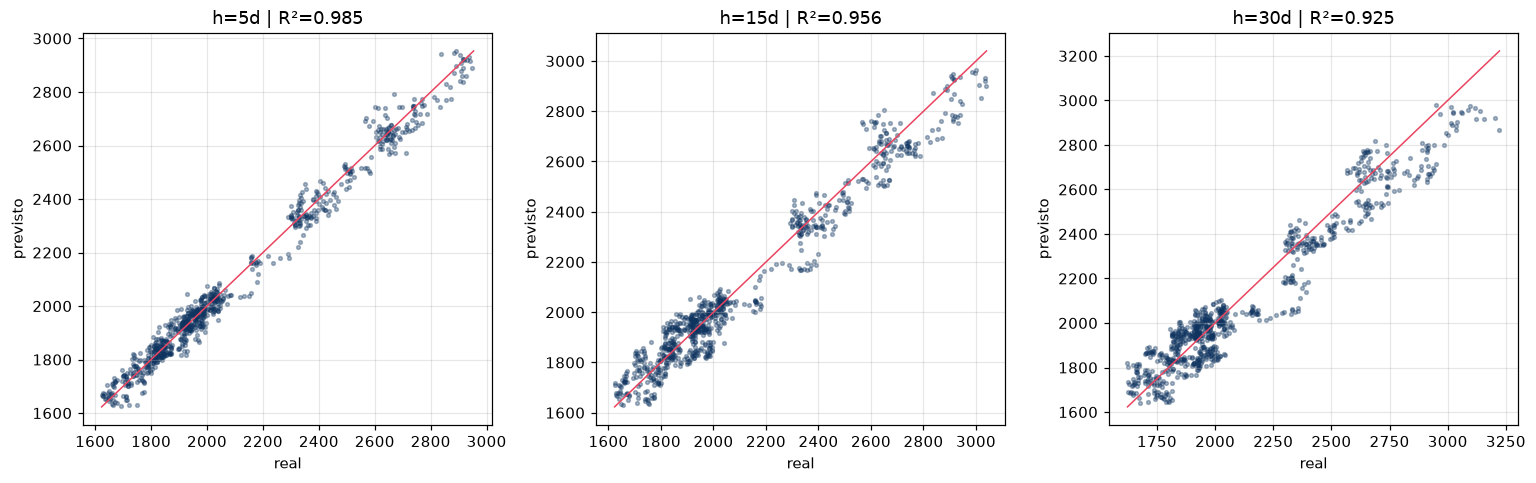

In [ ]:
fig = plot_scatter(
    Y_test,
    pred_test,
    P_test,
    HORIZONS,
)
fig.savefig(ARTIFACTS_DIR / "scatter_test.png", bbox_inches="tight")
show_or_close(fig)

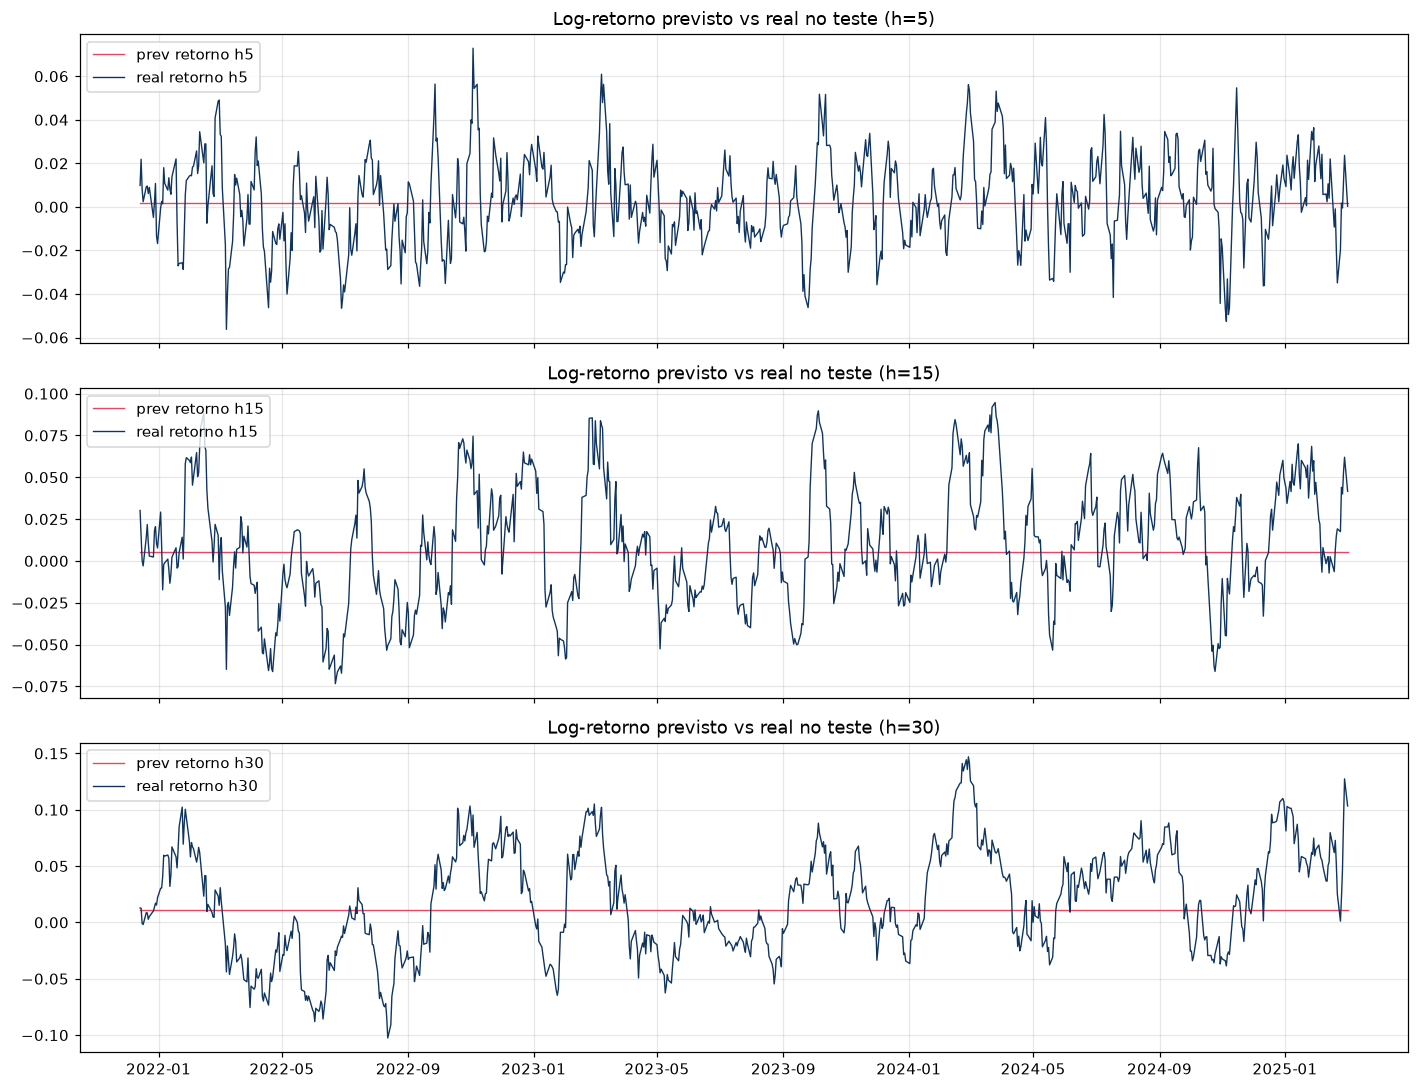

In [ ]:
fig = plot_return_predictions(
    dates_test,
    Y_test,
    pred_test,
    HORIZONS,
)
fig.savefig(ARTIFACTS_DIR / "returns_test.png", bbox_inches="tight")
show_or_close(fig)

In [ ]:
h30_idx = HORIZONS.index(30)
yearly = per_year_metrics(
    Y_test,
    pred_test,
    P_test,
    dates_test,
    horizon_idx=h30_idx,
)
yearly.to_csv(ARTIFACTS_DIR / "yearly_h30.csv")
yearly

,DirAcc%,MAE/naive
ano,,
2021,84.615385,0.552991
2022,50.199203,1.016010
2023,50.800000,1.048738
2024,77.380952,0.888242
2025,100.000000,0.838147


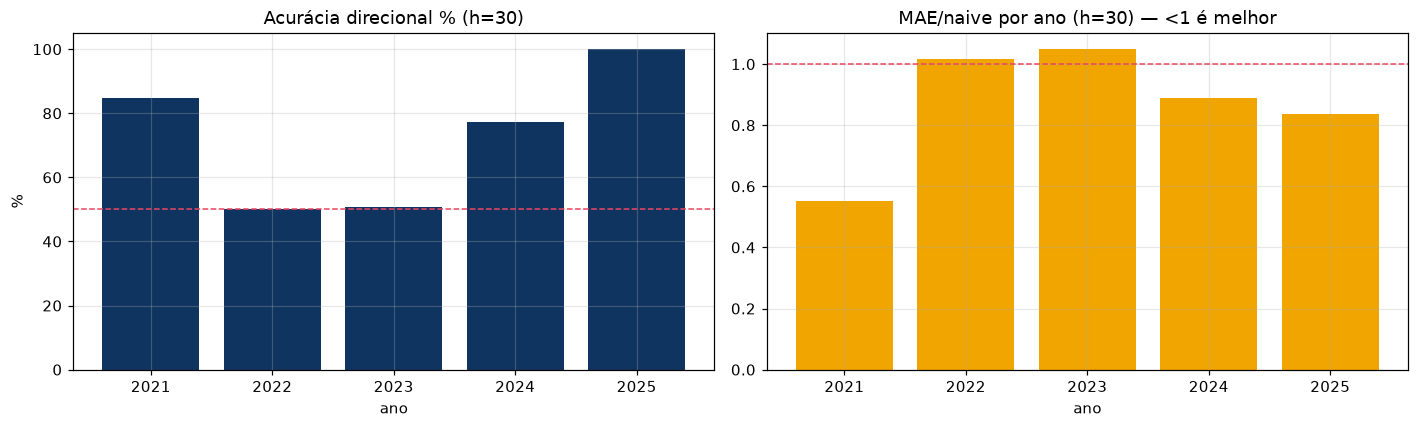

In [ ]:
fig = plot_yearly_perf(yearly, horizon=30)
fig.savefig(ARTIFACTS_DIR / "yearly_h30.png", bbox_inches="tight")
show_or_close(fig)

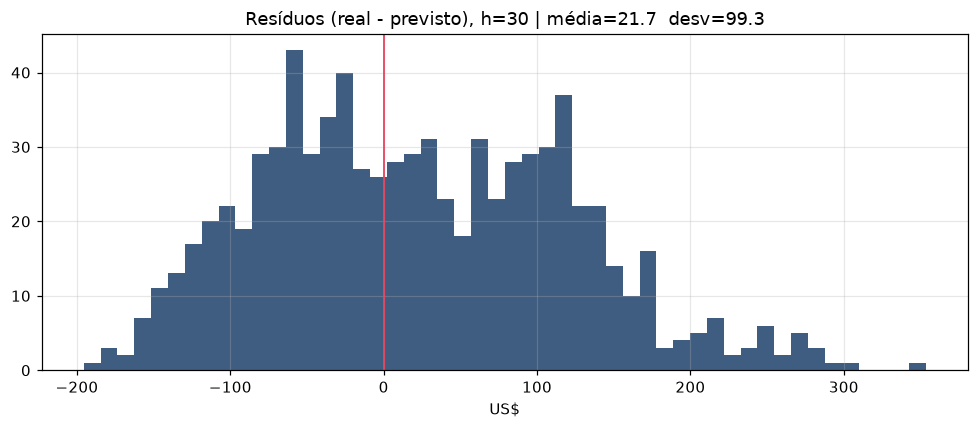

In [ ]:
fig = plot_residuals(
    Y_test,
    pred_test,
    P_test,
    horizon_idx=h30_idx,
    horizon=30,
)
fig.savefig(ARTIFACTS_DIR / "residuals_h30.png", bbox_inches="tight")
show_or_close(fig)

## Importância de features

In [ ]:
imp = pd.DataFrame(
    {f"h{h}": feature_importance_map[h] for h in HORIZONS},
    index=window_feature_names,
)
imp["mean"] = imp.mean(axis=1)
top_imp = imp.sort_values("mean", ascending=False).head(30)
top_imp.to_csv(ARTIFACTS_DIR / "feature_importance_top30.csv")
for h in HORIZONS:
    imp[[f"h{h}"]].sort_values(f"h{h}", ascending=False).head(30).to_csv(
        ARTIFACTS_DIR / f"feature_importance_top30_h{h}.csv"
    )
top_imp

,h5,h15,h30,mean
volume_t-59,0.0,0.0,0.0,0.0
log_ret_1_t-59,0.0,0.0,0.0,0.0
log_ret_5_t-59,0.0,0.0,0.0,0.0
log_ret_21_t-59,0.0,0.0,0.0,0.0
vol_5_t-59,0.0,0.0,0.0,0.0
vol_21_t-59,0.0,0.0,0.0,0.0
vol_ratio_t-59,0.0,0.0,0.0,0.0
dist_ma20_t-59,0.0,0.0,0.0,0.0
dist_ma50_t-59,0.0,0.0,0.0,0.0
ma_cross_t-59,0.0,0.0,0.0,0.0


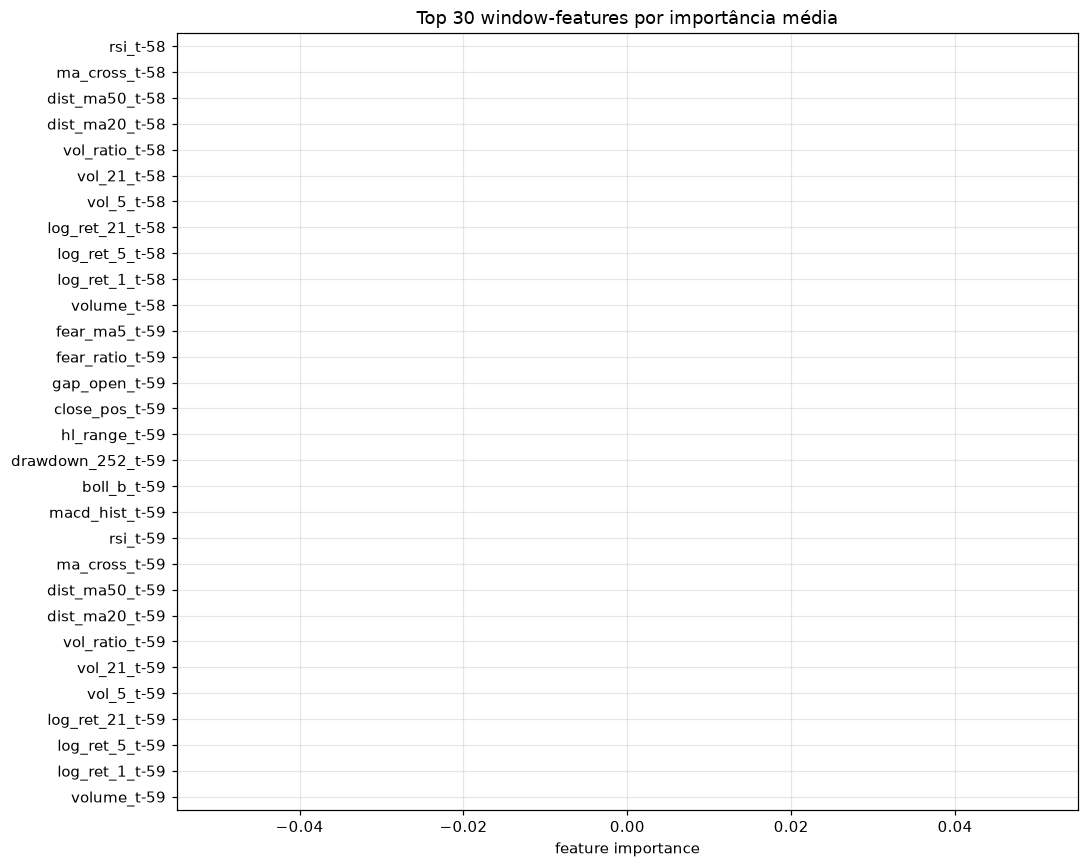

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
top_imp["mean"].sort_values().plot(kind="barh", ax=ax, color="#0f3460")
ax.set_title("Top 30 window-features por importância média")
ax.set_xlabel("feature importance")
plt.tight_layout()
fig.savefig(ARTIFACTS_DIR / "feature_importance_top30.png", bbox_inches="tight")
show_or_close(fig)

In [ ]:
print(f"Artefatos salvos em: {ARTIFACTS_DIR}")

Artefatos salvos em: /home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast/experiments/price_cnn/artifacts/gold_price_xgboost_cv_bayes
